In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Amey\Downloads\archive (2)\Advertising Budget and Sales.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


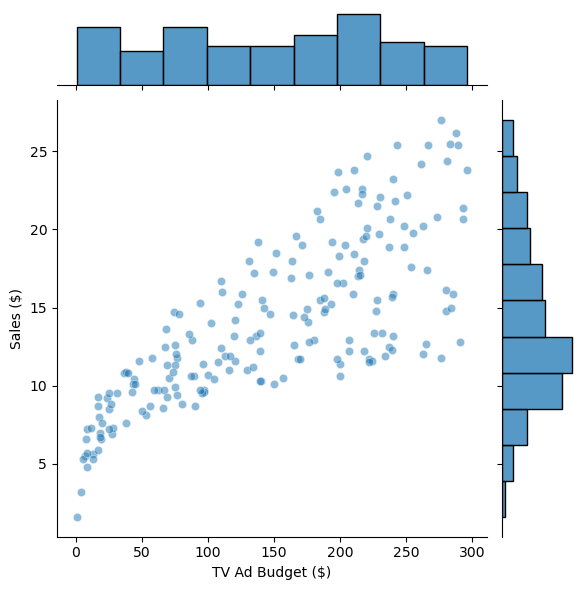

In [9]:
sns.jointplot(x='TV Ad Budget ($)', y= 'Sales ($)' , data= df, alpha = 0.5 )

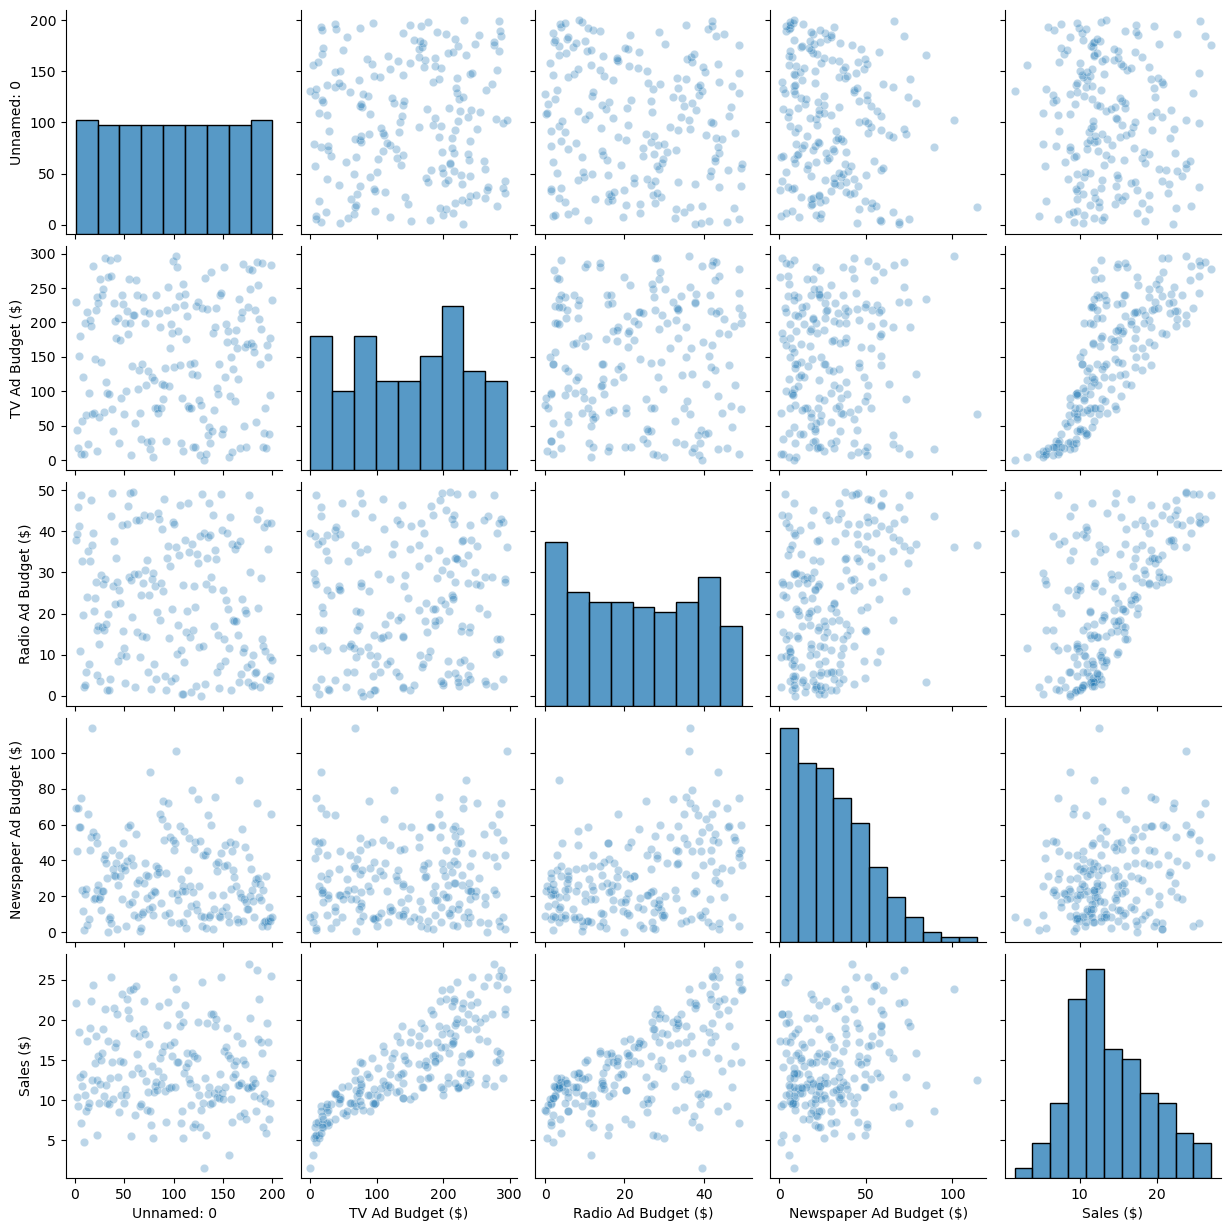

In [11]:
sns.pairplot(df , kind='scatter',plot_kws={'alpha':0.3})

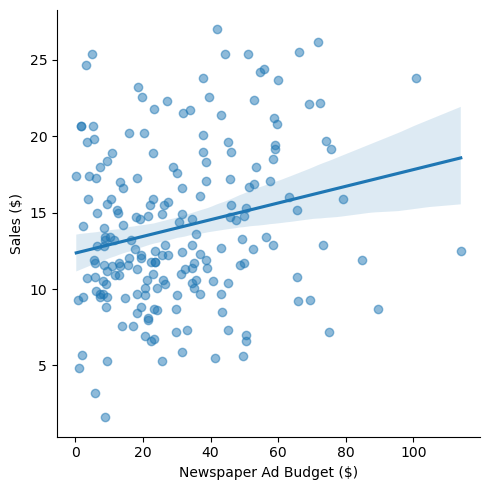

In [14]:
sns.lmplot(x='Newspaper Ad Budget ($)'
           ,y='Sales ($)'
           ,data= df
           , scatter_kws={'alpha':0.5})

In [12]:
from sklearn.model_selection import train_test_split

In [19]:
X = df[['Newspaper Ad Budget ($)','TV Ad Budget ($)','Radio Ad Budget ($)']]
y = df['Sales ($)']

In [20]:
X_train , X_test ,y_train,y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                     test_size=0.4)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
lm = LinearRegression()

In [23]:
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
X_test


,Newspaper Ad Budget ($),TV Ad Budget ($),Radio Ad Budget ($)
95,52.9,163.3,31.6
15,52.9,195.4,47.7
30,43.2,292.9,28.3
158,45.2,11.7,36.9
128,3.2,220.3,49.0
...,...,...,...
113,10.7,209.6,20.6
26,12.6,142.9,29.3
139,1.7,184.9,43.9
100,49.8,222.4,4.3


In [25]:
lm.coef_

array([0.0085429 , 0.04491068, 0.19843664])

In [29]:
cdf = pd.DataFrame(lm.coef_,X.columns ,  columns=['coef'])
print(cdf)

                             coef
Newspaper Ad Budget ($)  0.008543
TV Ad Budget ($)         0.044911
Radio Ad Budget ($)      0.198437


In [30]:
predictrions = lm.predict(X_test)
predictrions

array([16.63902413, 21.27548678, 21.72174077, 10.8164995 , 22.22714832,
       13.35087848, 21.26296358,  7.28718173, 13.35732452, 15.18037868,
        8.89761565,  6.49138646, 14.51326935,  8.83867006,  9.49159091,
       12.07490644,  8.84018706, 16.20182611, 10.27027547, 18.79536766,
       19.93298024, 13.8642087 , 12.38785643, 21.71127111,  7.53457962,
        5.56500602, 20.99254849, 11.80311964,  9.06161794,  8.37526001,
       12.25279138,  9.91469854, 21.830671  , 12.77700019, 18.26337691,
       20.13197086, 14.15091605, 21.11947555, 10.80927512,  4.31197375,
        9.51753508, 12.4319186 , 10.11635773,  8.0371654 , 13.2521022 ,
        5.15028895,  9.27682376, 14.10374127,  8.70521481, 11.60297218,
       15.67617324, 11.6638007 , 13.31758548, 11.08435278,  6.29895342,
        9.7925166 ,  9.3626635 , 24.42448277,  7.59664858, 12.20187455,
       17.5088018 , 15.24169083, 11.4355623 , 11.17957067, 16.52433204,
        6.81935356, 21.28044036,  6.02341036,  9.66588589, 11.55

Text(0.5, 1.0, 'evaluatine our ML model')

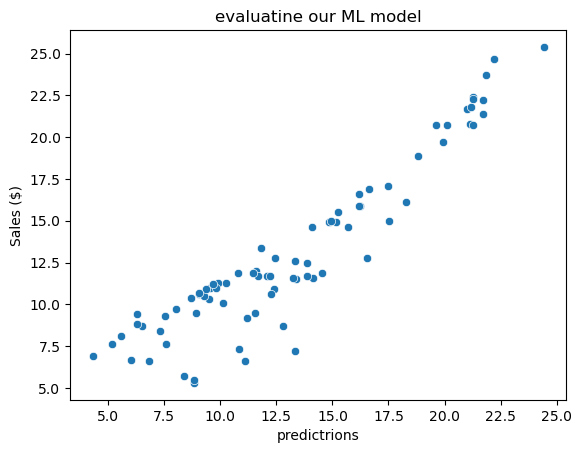

In [32]:
sns.scatterplot(x=predictrions,y=y_test)
plt.xlabel('predictrions')
plt.title('evaluatine our ML model')

In [34]:
from sklearn.metrics  import mean_absolute_error , mean_squared_error
import math

In [35]:
print("MSE:", mean_squared_error(y_test,predictrions))
print("MSE:", mean_absolute_error(y_test,predictrions))
print("RMSE:", math.sqrt(mean_squared_error(y_test,predictrions)))

MSE: 3.4290064802196305
MSE: 1.425969478596604
RMSE: 1.8517576731904286


In [36]:
residuals = y_test - predictrions
residuals

95     0.260976
15     1.124513
30    -0.321741
158   -3.516499
128    2.472852
         ...   
113   -0.275075
26     0.077837
139    1.087531
100   -2.149442
111    0.623708
Name: Sales ($), Length: 80, dtype: float64

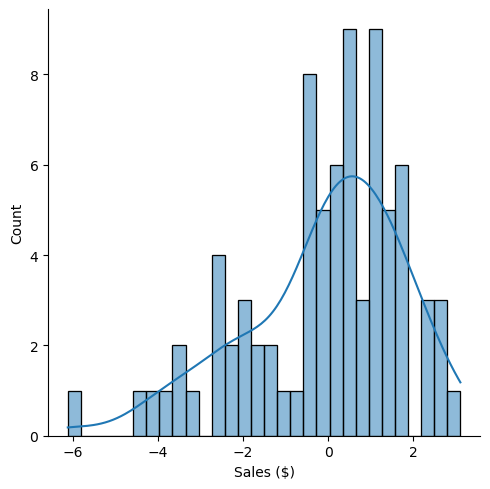

In [37]:
sns.displot(residuals,bins=30, kde = True)

In [40]:
import pylab
import scipy.stats as stats

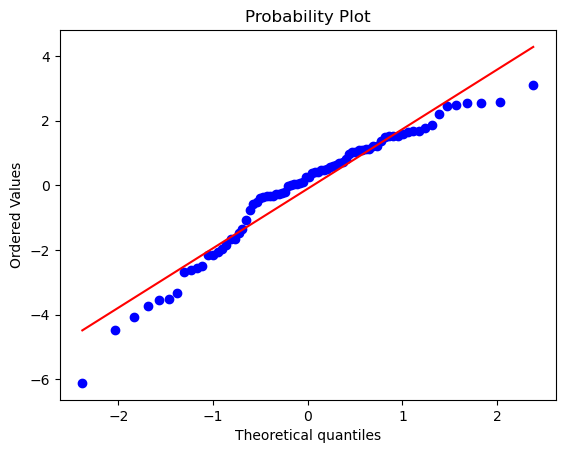

In [41]:
stats.probplot(residuals
               , dist='norm'
               ,plot=pylab)

pylab.show()